# 01 - EDA Notebook (Palmer Penguins)

Objetivos:
- Carregar dados da fonte oficial
- Executar as mesmas análises do pipeline EDA
- Exibir os mesmos tipos de gráficos inline
- Gerar parquet limpo para a etapa de ML

In [1]:
%matplotlib inline

import warnings
from pathlib import Path

import polars as pl
import seaborn as sns
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore", category=DeprecationWarning)
sns.set_theme(style="whitegrid", context="talk")

PENGUINS_URL = "https://raw.githubusercontent.com/mcnakhaee/palmerpenguins/master/palmerpenguins/data/penguins.csv"
PENGUIN_PALETTE = ["#1B4965", "#5FA8D3", "#62B6CB", "#CAE9FF", "#0B132B"]

## Funcoes de Carregamento e Padronizacao

In [2]:
def load_penguins(url=None):
    url = url or PENGUINS_URL
    df = pl.read_csv(url, null_values=["NA", "na", ""])
    return standardize_types(df)


def standardize_types(df):
    numeric_cols = ["bill_length_mm", "bill_depth_mm", "flipper_length_mm", "body_mass_g"]

    for col in numeric_cols:
        if col in df.columns:
            df = df.with_columns(pl.col(col).cast(pl.Float64, strict=False))

    for col in ["species", "island", "sex"]:
        if col in df.columns:
            df = df.with_columns(pl.col(col).str.to_lowercase())

    return df

## Funcoes de Analise

In [3]:
def missing_summary(df):
    missing_counts = [{"column": col, "missing_count": df[col].null_count()} for col in df.columns]
    return pl.DataFrame(missing_counts).sort("missing_count", descending=True)


def rows_with_missing(df):
    exprs = [pl.col(c).is_null() for c in df.columns]
    return df.filter(pl.any_horizontal(exprs))


def island_counts(df):
    return df.group_by("island").agg(pl.len().alias("count")).sort("count", descending=True)


def species_counts(df):
    return df.group_by("species").agg(pl.len().alias("count")).sort("count", descending=True)


def species_stats(df):
    return (
        df.group_by("species")
        .agg(
            pl.col("bill_length_mm").mean().alias("bill_length_mm_mean"),
            pl.col("bill_depth_mm").mean().alias("bill_depth_mm_mean"),
            pl.col("flipper_length_mm").mean().alias("flipper_length_mm_mean"),
            pl.col("body_mass_g").mean().alias("body_mass_g_mean"),
        )
        .sort("species")
    )


def sex_species_stats(df):
    return (
        df.filter(pl.col("sex").is_not_null())
        .group_by("species", "sex")
        .agg(
            pl.len().alias("n"),
            pl.col("bill_length_mm").mean().alias("bill_length_mm_mean"),
            pl.col("bill_depth_mm").mean().alias("bill_depth_mm_mean"),
            pl.col("flipper_length_mm").mean().alias("flipper_length_mm_mean"),
            pl.col("body_mass_g").mean().alias("body_mass_g_mean"),
        )
        .sort("species", "sex")
    )


def compute_all_analyses(df):
    return {
        "missing_summary": missing_summary(df),
        "missing_rows": rows_with_missing(df),
        "island_counts": island_counts(df),
        "species_counts": species_counts(df),
        "species_stats": species_stats(df),
        "sex_species_stats": sex_species_stats(df),
    }

## Fase 1 - Carregamento

In [4]:
df = load_penguins()
print(f"Dataset carregado: {df.shape[0]} registros x {df.shape[1]} colunas")
print(f"Colunas: {df.columns}")
df.head()

Dataset carregado: 344 registros x 8 colunas
Colunas: ['species', 'island', 'bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g', 'sex', 'year']


species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year
str,str,f64,f64,f64,f64,str,i64
"""adelie""","""torgersen""",39.1,18.7,181.0,3750.0,"""male""",2007
"""adelie""","""torgersen""",39.5,17.4,186.0,3800.0,"""female""",2007
"""adelie""","""torgersen""",40.3,18.0,195.0,3250.0,"""female""",2007
"""adelie""","""torgersen""",null,null,null,null,null,2007
"""adelie""","""torgersen""",36.7,19.3,193.0,3450.0,"""female""",2007


## Fase 2 - Analises

In [5]:
analyses = compute_all_analyses(df)

missing_summary_df = analyses["missing_summary"]
missing_rows_df = analyses["missing_rows"]
island_counts_df = analyses["island_counts"]
species_counts_df = analyses["species_counts"]
species_stats_df = analyses["species_stats"]
sex_species_stats_df = analyses["sex_species_stats"]

print("Resumo de dados faltantes:")
display(missing_summary_df)

print("\nLinhas com valores faltantes (amostra):")
display(missing_rows_df.head(10))

print("\nContagem por ilha:")
display(island_counts_df)

print("\nContagem por especie:")
display(species_counts_df)

print("\nMedias por especie:")
display(species_stats_df)

print("\nMedias por especie e sexo:")
display(sex_species_stats_df)

Resumo de dados faltantes:


column,missing_count
str,i64
"""sex""",11
"""bill_length_mm""",2
"""bill_depth_mm""",2
"""flipper_length_mm""",2
"""body_mass_g""",2
"""species""",0
"""island""",0
"""year""",0



Linhas com valores faltantes (amostra):


species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year
str,str,f64,f64,f64,f64,str,i64
"""adelie""","""torgersen""",null,null,null,null,null,2007
"""adelie""","""torgersen""",34.1,18.1,193.0,3475.0,null,2007
"""adelie""","""torgersen""",42.0,20.2,190.0,4250.0,null,2007
"""adelie""","""torgersen""",37.8,17.1,186.0,3300.0,null,2007
"""adelie""","""torgersen""",37.8,17.3,180.0,3700.0,null,2007
"""adelie""","""dream""",37.5,18.9,179.0,2975.0,null,2007
"""gentoo""","""biscoe""",44.5,14.3,216.0,4100.0,null,2007
"""gentoo""","""biscoe""",46.2,14.4,214.0,4650.0,null,2008
"""gentoo""","""biscoe""",47.3,13.8,216.0,4725.0,null,2009



Contagem por ilha:


...

species,count
str,u32
"""adelie""",152
"""gentoo""",124
"""chinstrap""",68



Medias por especie:


species,bill_length_mm_mean,bill_depth_mm_mean,flipper_length_mm_mean,body_mass_g_mean
str,f64,f64,f64,f64
"""adelie""",38.791391,18.346358,189.953642,3700.662252
"""chinstrap""",48.833824,18.420588,195.823529,3733.088235
"""gentoo""",47.504878,14.982114,217.186992,5076.01626



Medias por especie e sexo:


species,sex,n,bill_length_mm_mean,bill_depth_mm_mean,flipper_length_mm_mean,body_mass_g_mean
str,str,u32,f64,f64,f64,f64
"""adelie""","""female""",73,37.257534,17.621918,187.794521,3368.835616
"""adelie""","""male""",73,40.390411,19.072603,192.410959,4043.493151
"""chinstrap""","""female""",34,46.573529,17.588235,191.735294,3527.205882
"""chinstrap""","""male""",34,51.094118,19.252941,199.911765,3938.970588
"""gentoo""","""female""",58,45.563793,14.237931,212.706897,4679.741379
"""gentoo""","""male""",61,49.47377,15.718033,221.540984,5484.836066


## Fase 3 - Visualizacoes Inline

In [6]:
def autopct_with_counts(values):
    total = sum(values)

    def formatter(pct):
        count = int(round(pct * total / 100.0))
        return f"{pct:.1f}% ({count})"

    return formatter

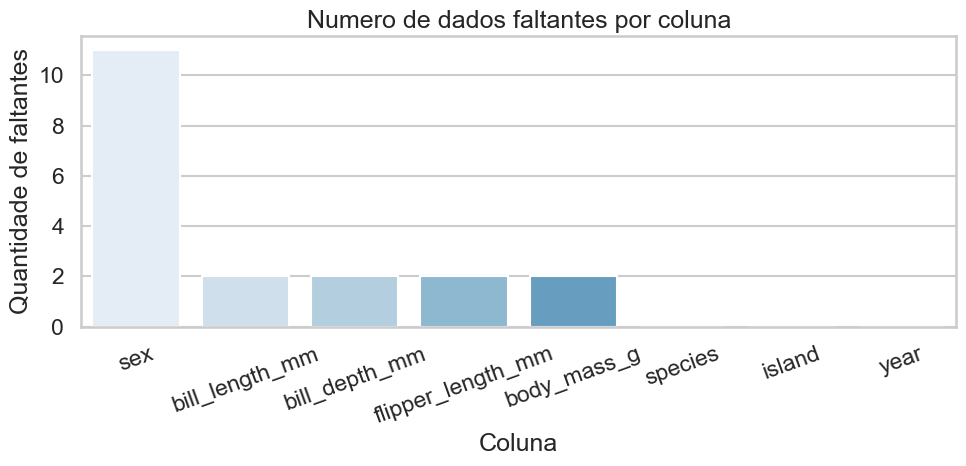

In [7]:
# Grafico 1 - Dados faltantes por coluna
plt.figure(figsize=(10, 5))
data = missing_summary_df.to_dict(as_series=False)
palette = sns.color_palette("Blues", n_colors=len(data["column"]))
sns.barplot(x=data["column"], y=data["missing_count"], hue=data["column"], palette=palette, legend=False)
plt.title("Numero de dados faltantes por coluna")
plt.xlabel("Coluna")
plt.ylabel("Quantidade de faltantes")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

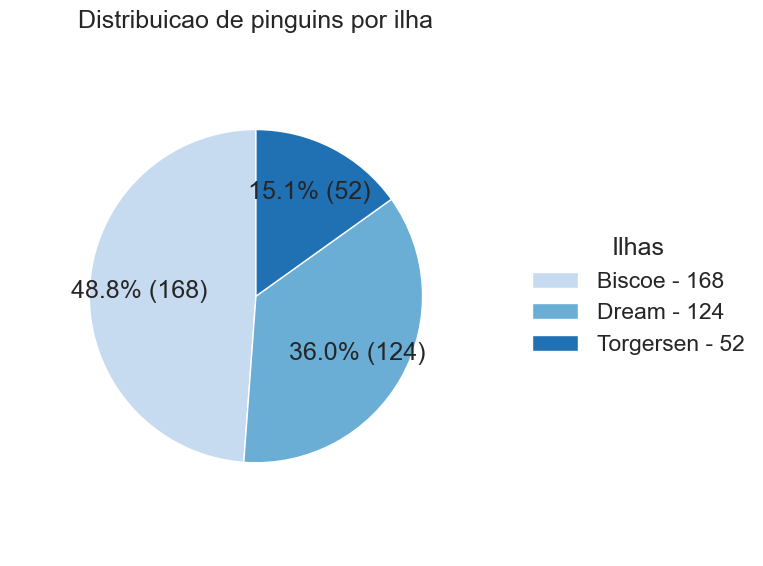

In [8]:
# Grafico 2 - Distribuicao por ilha
plt.figure(figsize=(8, 6))
data = island_counts_df.to_dict(as_series=False)
counts = data["count"]
islands = data["island"]
palette = sns.color_palette("Blues", n_colors=len(islands))
wedges, _, _ = plt.pie(counts, labels=None, autopct=autopct_with_counts(counts), startangle=90, colors=palette, pctdistance=0.7, wedgeprops={"edgecolor": "white", "linewidth": 1})
plt.title("Distribuicao de pinguins por ilha")
legend_labels = [f"{name.title()} - {count}" for name, count in zip(islands, counts)]
plt.legend(wedges, legend_labels, title="Ilhas", loc="center left", bbox_to_anchor=(1.02, 0.5), frameon=False)
plt.axis("equal")
plt.tight_layout()
plt.show()

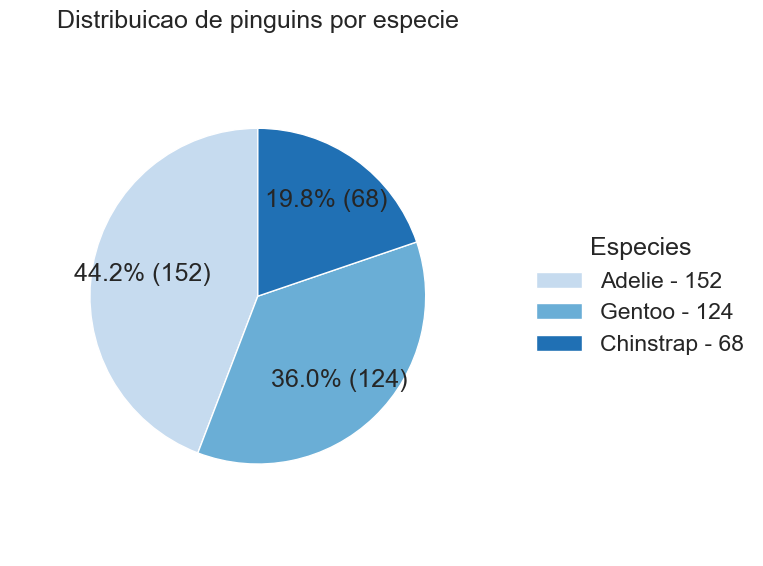

In [9]:
# Grafico 3 - Distribuicao por especie
plt.figure(figsize=(8, 6))
data = species_counts_df.to_dict(as_series=False)
counts = data["count"]
species = data["species"]
palette = sns.color_palette("Blues", n_colors=len(species))
wedges, _, _ = plt.pie(counts, labels=None, autopct=autopct_with_counts(counts), startangle=90, colors=palette, pctdistance=0.7, wedgeprops={"edgecolor": "white", "linewidth": 1})
plt.title("Distribuicao de pinguins por especie")
legend_labels = [f"{name.capitalize()} - {count}" for name, count in zip(species, counts)]
plt.legend(wedges, legend_labels, title="Especies", loc="center left", bbox_to_anchor=(1.02, 0.5), frameon=False)
plt.axis("equal")
plt.tight_layout()
plt.show()

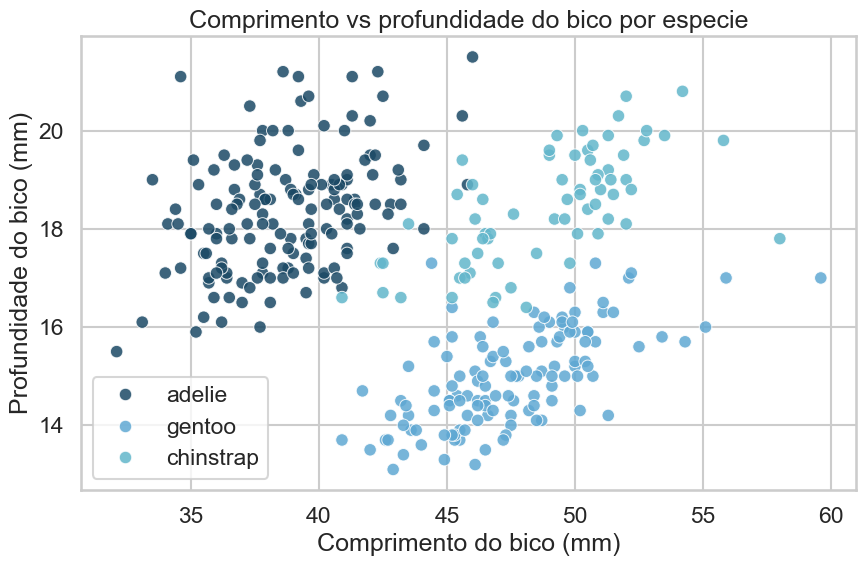

In [10]:
# Grafico 4 - Bill length x Bill depth por especie
plt.figure(figsize=(9, 6))
clean_scatter = df.drop_nulls(["bill_length_mm", "bill_depth_mm", "species"])
scatter_data = clean_scatter.to_dict(as_series=False)
sns.scatterplot(x=scatter_data["bill_length_mm"], y=scatter_data["bill_depth_mm"], hue=scatter_data["species"], palette=PENGUIN_PALETTE[:3], alpha=0.85)
plt.title("Comprimento vs profundidade do bico por especie")
plt.xlabel("Comprimento do bico (mm)")
plt.ylabel("Profundidade do bico (mm)")
plt.tight_layout()
plt.show()

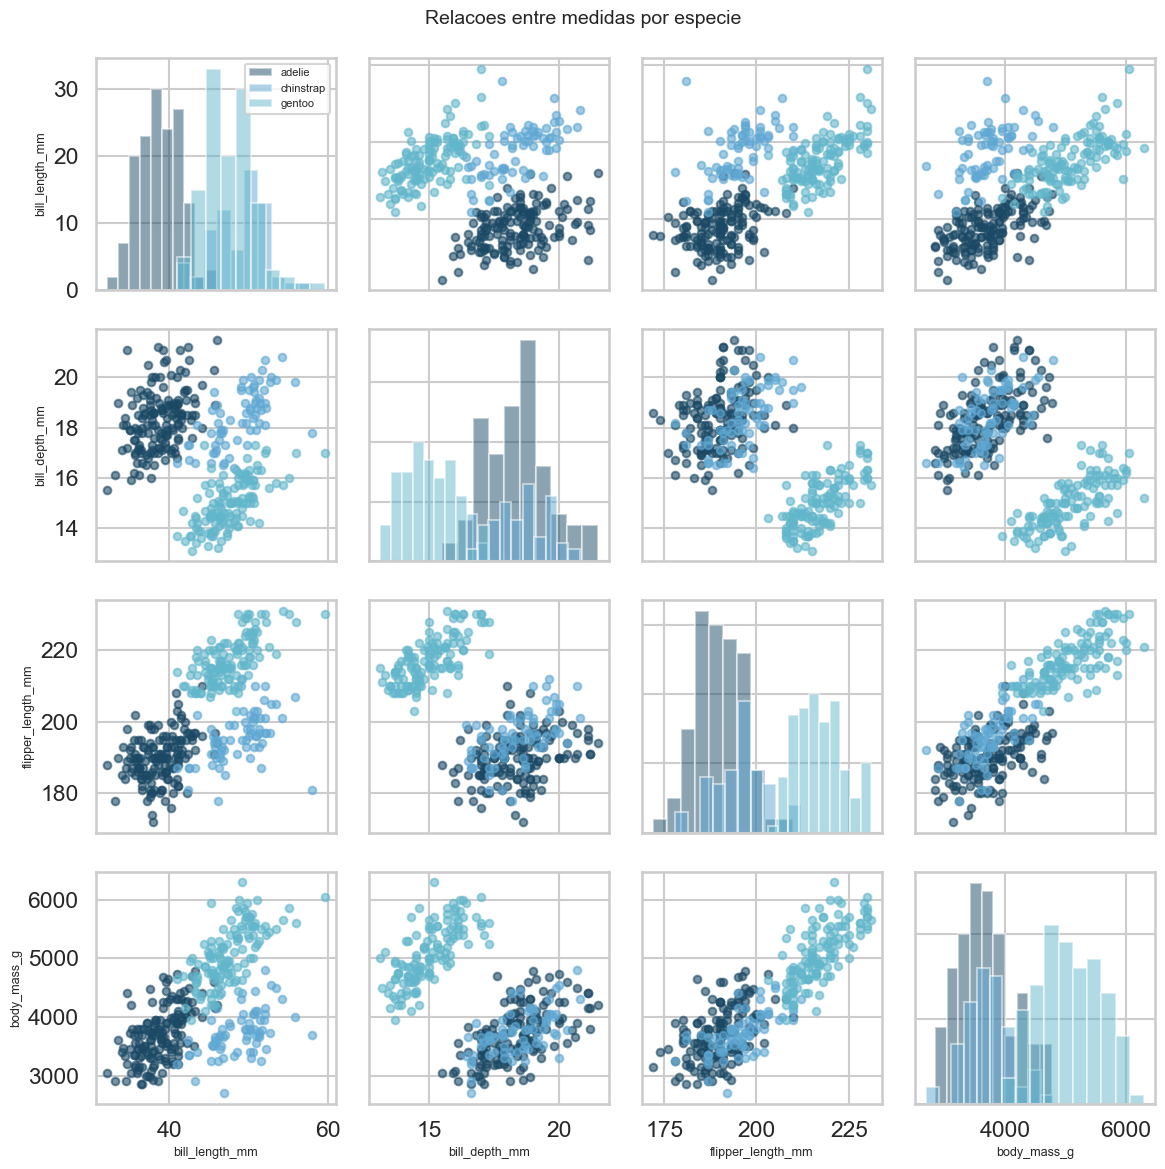

In [11]:
# Grafico 5 - Pairplot custom por especie
cols = ["bill_length_mm", "bill_depth_mm", "flipper_length_mm", "body_mass_g"]
clean_df = df.select(["species"] + cols).drop_nulls()
data = clean_df.to_dict(as_series=False)

n_cols = len(cols)
fig, axes = plt.subplots(n_cols, n_cols, figsize=(12, 12))

species_list = sorted(list(set(data["species"])))
species_colors = {sp: PENGUIN_PALETTE[i % len(PENGUIN_PALETTE)] for i, sp in enumerate(species_list)}

for i, col_y in enumerate(cols):
    for j, col_x in enumerate(cols):
        ax = axes[i, j]
        if i == j:
            for sp in species_list:
                mask = [s == sp for s in data["species"]]
                values = [data[col_x][k] for k in range(len(data["species"])) if mask[k]]
                ax.hist(values, alpha=0.5, label=sp, color=species_colors[sp], bins=10)
            if i == 0:
                ax.legend(fontsize=8)
        else:
            for sp in species_list:
                mask = [s == sp for s in data["species"]]
                x_vals = [data[col_x][k] for k in range(len(data["species"])) if mask[k]]
                y_vals = [data[col_y][k] for k in range(len(data["species"])) if mask[k]]
                ax.scatter(x_vals, y_vals, alpha=0.6, color=species_colors[sp], s=30)

        if i == n_cols - 1:
            ax.set_xlabel(col_x, fontsize=9)
        else:
            ax.set_xticklabels([])

        if j == 0:
            ax.set_ylabel(col_y, fontsize=9)
        else:
            ax.set_yticklabels([])

fig.suptitle("Relacoes entre medidas por especie", fontsize=14)
plt.tight_layout()
plt.show()

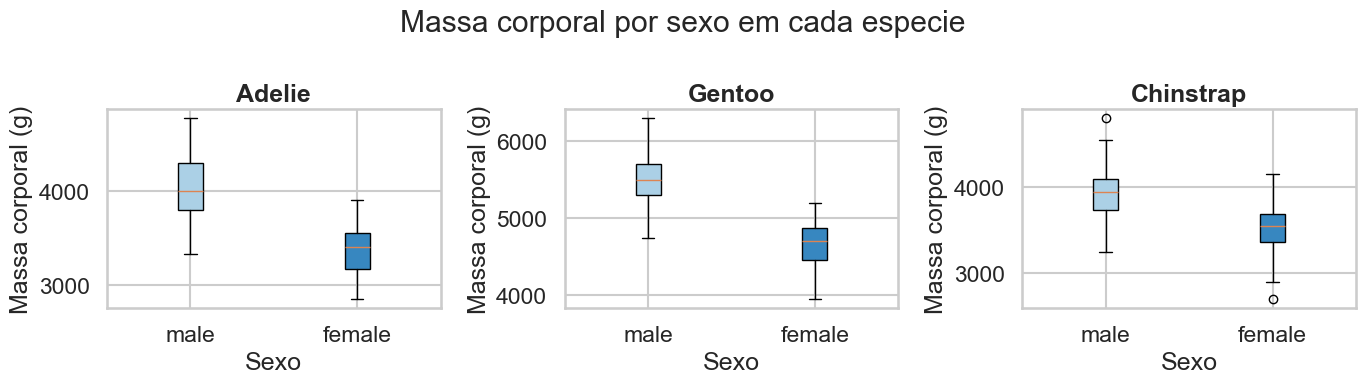

In [12]:
# Grafico 6 - Massa corporal por sexo em cada especie
clean_df = df.filter(pl.col("sex").is_not_null()).select(["species", "sex", "body_mass_g"])
species_list = ["adelie", "gentoo", "chinstrap"]
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
palette = sns.color_palette("Blues", n_colors=2)

for idx, sp in enumerate(species_list):
    ax = axes[idx]
    species_data = clean_df.filter(pl.col("species") == sp)
    if species_data.height == 0:
        continue

    data_dict = species_data.to_dict(as_series=False)
    males = [data_dict["body_mass_g"][i] for i in range(len(data_dict["sex"])) if data_dict["sex"][i] == "male"]
    females = [data_dict["body_mass_g"][i] for i in range(len(data_dict["sex"])) if data_dict["sex"][i] == "female"]

    box_data = []
    labels = []
    if males:
        box_data.append(males)
        labels.append("male")
    if females:
        box_data.append(females)
        labels.append("female")

    if box_data:
        bp = ax.boxplot(box_data, labels=labels, patch_artist=True)
        for patch, color in zip(bp["boxes"], palette[:len(box_data)]):
            patch.set_facecolor(color)

    ax.set_title(sp.capitalize(), fontweight="bold")
    ax.set_ylabel("Massa corporal (g)")
    ax.set_xlabel("Sexo")

fig.suptitle("Massa corporal por sexo em cada especie")
plt.tight_layout()
plt.show()

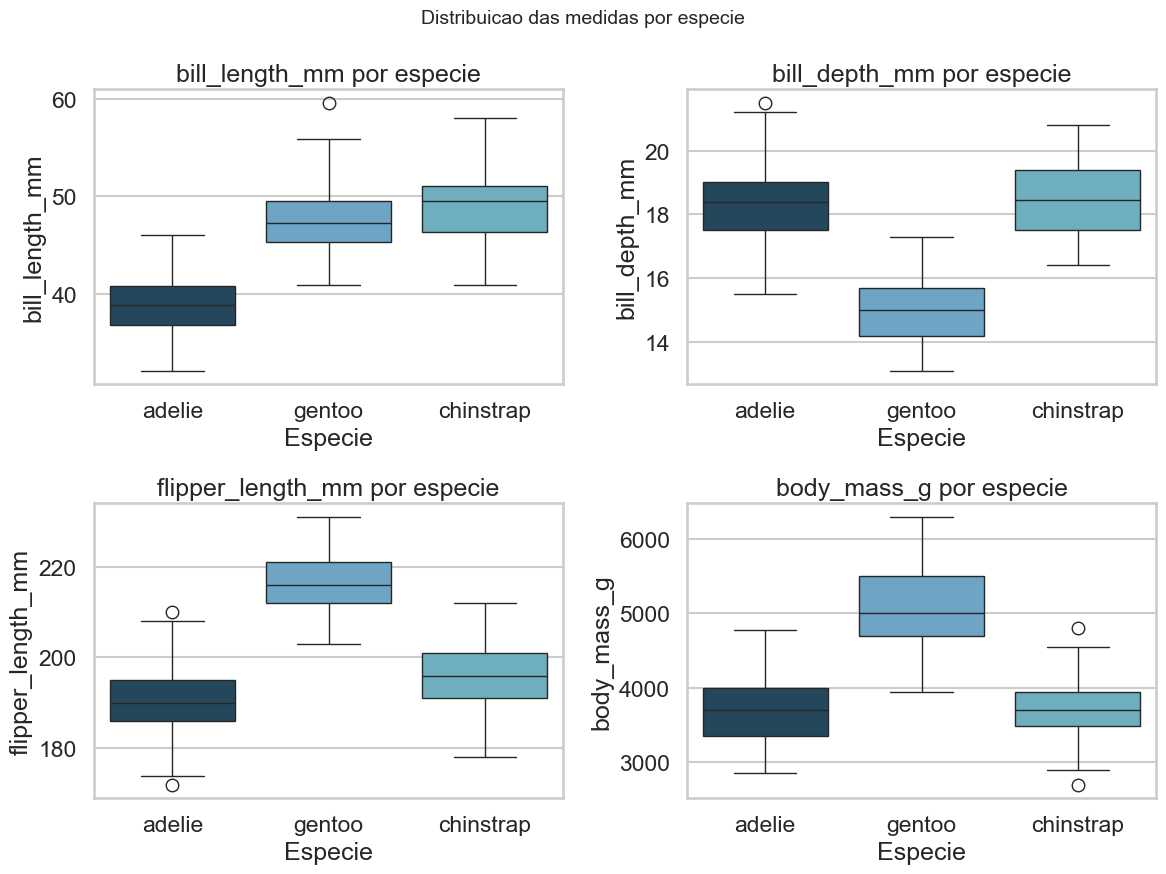

In [13]:
# Grafico 7 - Boxplot de medidas por especie
measure_cols = ["bill_length_mm", "bill_depth_mm", "flipper_length_mm", "body_mass_g"]
fig, axes = plt.subplots(2, 2, figsize=(12, 9))
axes = axes.flatten()

for idx, col in enumerate(measure_cols):
    ax = axes[idx]
    measure_df = df.select(["species", col]).drop_nulls()
    data = measure_df.to_dict(as_series=False)
    sns.boxplot(x=data["species"], y=data[col], hue=data["species"], palette=PENGUIN_PALETTE[:3], legend=False, ax=ax)
    ax.set_title(f"{col} por especie")
    ax.set_xlabel("Especie")
    ax.set_ylabel(col)

fig.suptitle("Distribuicao das medidas por especie", fontsize=14)
plt.tight_layout()
plt.show()

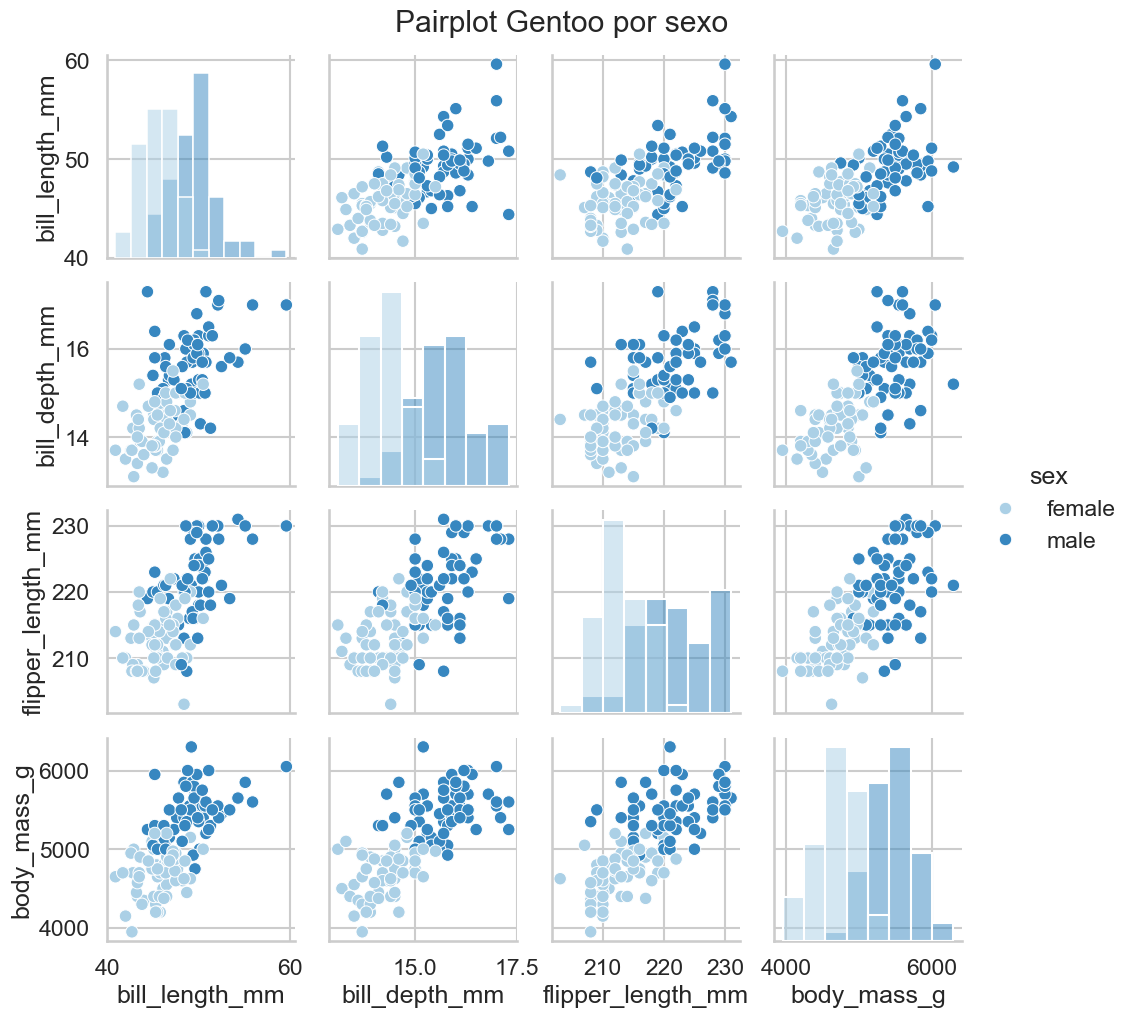

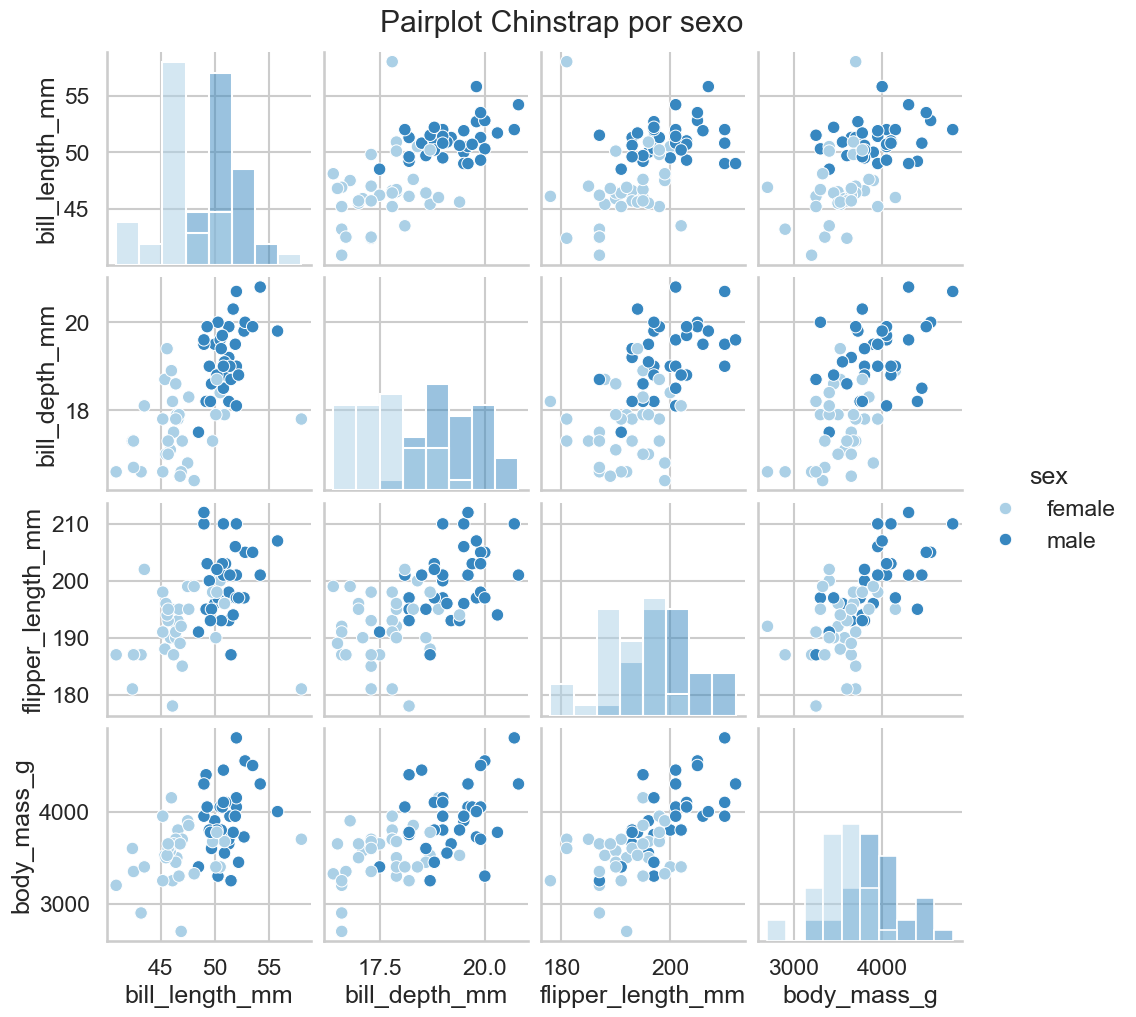

In [14]:
# Graficos 8 e 9 - Pairplots por especie com hue de sexo
def plot_pair_by_species(species_name):
    subset = df.filter(pl.col("species") == species_name).drop_nulls(["sex", "bill_length_mm", "bill_depth_mm", "flipper_length_mm", "body_mass_g"])
    pdf = subset.select(["sex", "bill_length_mm", "bill_depth_mm", "flipper_length_mm", "body_mass_g"]).to_pandas()
    sns.pairplot(pdf, vars=["bill_length_mm", "bill_depth_mm", "flipper_length_mm", "body_mass_g"], hue="sex", diag_kind="hist", palette="Blues")
    plt.suptitle(f"Pairplot {species_name.capitalize()} por sexo", y=1.02)
    plt.show()

plot_pair_by_species("gentoo")
plot_pair_by_species("chinstrap")

## Fase 4 - Exportacao do Dataset Limpo

In [15]:
Path("dataset").mkdir(parents=True, exist_ok=True)
df_clean = df.drop_nulls()
output_path = Path("dataset/penguins_clean.parquet")
df_clean.write_parquet(output_path)
print(f"Arquivo salvo: {output_path} | shape: {df_clean.shape}")

Arquivo salvo: dataset/penguins_clean.parquet | shape: (333, 8)
